In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

from trompy import save_figure_atomic

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["savefig.transparent"] = True

In [2]:
def tweak_df(df):

    return (
        df
        .assign(total_NR=lambda df_: df_.test1_NR + df_.test2_NR)
        .assign(total_PR=lambda df_: df_.test1_PR + df_.test2_PR)
        .assign(test1_both=lambda df_: df_.test1_NR + df_.test1_PR)
        .assign(test2_both=lambda df_: df_.test2_NR + df_.test2_PR)
    )

df = pd.read_csv(Path("../data/pilot_pellets.csv"), sep=";")
df = tweak_df(df)

In [3]:
df

,id,test1_NR,test1_PR,test2_NR,test2_PR,total_NR,total_PR,test1_both,test2_both
0,FEDXDM21,1,3,1,9,2,12,4,10
1,FEDXDM22,0,1,0,5,0,6,1,5
2,FEDXDM23,0,4,0,9,0,13,4,9
3,FEDXDM24,1,1,5,4,6,5,2,9
4,FEDXDM25,0,4,7,1,7,5,4,8
5,FEDXDM26,2,3,1,10,3,13,5,11


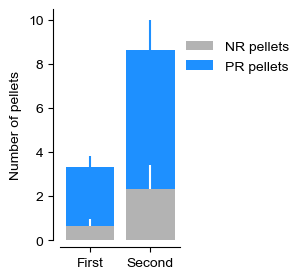

In [4]:
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

f, ax = plt.subplots(figsize=(4, 3),
                     gridspec_kw={"left": 0.3, "right": 0.6},)
ax.bar(1, np.mean(df.test1_NR),
       yerr=[[0], [np.std(df.test1_NR)/np.sqrt(6)]],
       color=color_nr,
       alpha=0.5,
       ecolor="white",
       label="NR pellets")
ax.bar(1, np.mean(df.test1_PR),
       bottom=np.mean(df.test1_NR),
       yerr=np.std(df.test1_PR)/np.sqrt(6),
       color=color_pr,
       ecolor=color_pr,
       label="PR pellets")
ax.bar(2, np.mean(df.test2_NR),
       yerr=[[0], [np.std(df.test2_NR)/np.sqrt(6)]],
       color=color_nr,
       alpha=0.5,
       ecolor="white")
ax.bar(2, np.mean(df.test2_PR),
       bottom=np.mean(df.test2_NR),
       yerr=np.std(df.test2_PR)/np.sqrt(6),
       color=color_pr,
       ecolor=color_pr)

ax .set_ylabel("Number of pellets")
ax.set_xticks([1, 2], labels=["First", "Second"])

ax.legend(loc=(1,0.7), frameon=False, fontsize=10)

sns.despine(offset=5)

save_figure_atomic(f, "pilot_pellets.pdf", Path("../plots"))

